# 03 · Análisis Exploratorio de Datos (EDA)

**Proyecto:** Predicción de transiciones de privación básica en hogares colombianos  
**Fuente:** Encuesta Longitudinal Colombiana (ELCA) 2010–2016  
**Autores:** Talia Linares · Camilo Rendón · Nicolás Cubillos · Alejandro Velandia

---

> ⚠️ **Requisito:** `base_con_variables.csv` generada por el notebook 02.
>
> ℹ️ **Paso 4 del flujo de la docente:** El EDA se realiza **únicamente sobre los datos de entrenamiento (80%)**. El conjunto de prueba queda reservado y solo se usa en el notebook 04 para la evaluación final, evitando fuga de información.

In [1]:
from google.colab import files
import os

if os.path.exists('/content/base_con_variables.csv'):
    print("base_con_variables.csv disponible.")
else:
    print("Sube base_con_variables.csv:")
    uploaded = files.upload()

os.makedirs('/content/outputs', exist_ok=True)

Sube base_con_variables.csv:


Saving base_con_variables.csv to base_con_variables.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
sns.set_style('whitegrid')

COLORES = {0:'#2E86AB', 1:'#E84855', 2:'#3BB273', 3:'#F7B731'}
TRANS   = {0:'Estable', 1:'Vulnerable', 2:'Mov. ascendente', 3:'Crónico'}
ZONA    = {0:'Rural', 1:'Urbano'}

df_completo = pd.read_csv('/content/base_con_variables.csv')
df_completo['zona']    = pd.to_numeric(df_completo['zona'], errors='coerce').fillna(0).astype(int)
df_completo['estrato'] = pd.to_numeric(df_completo['estrato'], errors='coerce')

# ============================================================
# PASO 4 DEL FLUJO: EDA SOLO EN DATOS DE ENTRENAMIENTO
# El conjunto de prueba queda guardado y no se usa hasta el
# notebook 04. Esto evita fuga de información (data leakage).
# ============================================================
cols_excluir = ['transicion','par_ondas','id_hogar','transicion_label','zona_label']
features     = [c for c in df_completo.columns if c not in cols_excluir]

X_train, X_test, y_train, y_test = train_test_split(
    df_completo[features], df_completo['transicion'],
    test_size=0.2, random_state=42, stratify=df_completo['transicion']
)

# Construir df de EDA solo con datos de entrenamiento
df = X_train.copy()
df['transicion']       = y_train.values
df['transicion_label'] = df['transicion'].map(TRANS)
df['zona_label']       = df['zona'].map(ZONA).fillna('Desconocida')

print("=" * 55)
print("EDA SOBRE DATOS DE ENTRENAMIENTO (80%)")
print("=" * 55)
print(f"Base completa:          {len(df_completo):,} hogares")
print(f"Entrenamiento (EDA):    {len(df):,} hogares ← usamos estos")
print(f"Prueba (reservado):     {len(X_test):,} hogares ← notebook 04")
print()
print("Distribución de transición en train:")
for k,v in TRANS.items():
    n = (df['transicion']==k).sum()
    print(f"  {v:<22} {n:,} ({n/len(df)*100:.1f}%)")

EDA SOBRE DATOS DE ENTRENAMIENTO (80%)
Base completa:          16,957 hogares
Entrenamiento (EDA):    13,565 hogares ← usamos estos
Prueba (reservado):     3,392 hogares ← notebook 04

Distribución de transición en train:
  Estable                6,532 (48.2%)
  Vulnerable             1,422 (10.5%)
  Mov. ascendente        1,634 (12.0%)
  Crónico                3,977 (29.3%)


---
## 1. Variable dependiente: transiciones

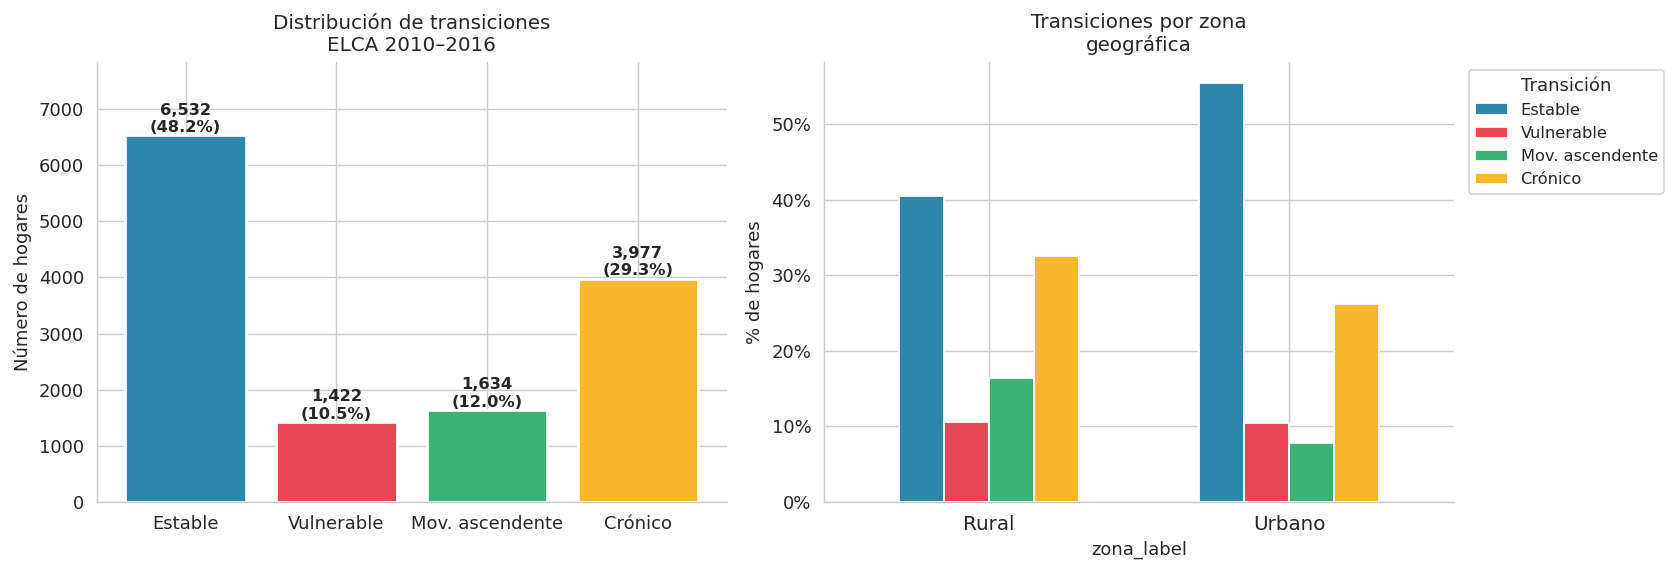

Insight: 77.5% no cambia de estado (Estable + Crónico).


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Conteo por clase
conteos = df['transicion'].value_counts().sort_index()
bars = axes[0].bar([TRANS[i] for i in conteos.index], conteos.values,
                    color=[COLORES[i] for i in conteos.index], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, conteos.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Número de hogares')
axes[0].set_title('Distribución de transiciones\nELCA 2010–2016', fontsize=11)
axes[0].set_ylim(0, conteos.max()*1.2)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Por zona
pct_zona = pd.crosstab(df['zona_label'], df['transicion_label'], normalize='index')*100
pct_zona = pct_zona.reindex(columns=[TRANS[i] for i in range(4)], fill_value=0)
pct_zona.plot(kind='bar', ax=axes[1], color=[COLORES[i] for i in range(4)],
              edgecolor='white', linewidth=1, width=0.6)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, fontsize=11)
axes[1].set_ylabel('% de hogares')
axes[1].set_title('Transiciones por zona\ngeográfica', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title='Transición', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/outputs/eda_transiciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: 77.5% no cambia de estado (Estable + Crónico).")

---
## 2. IPBH: incidencia e intensidad

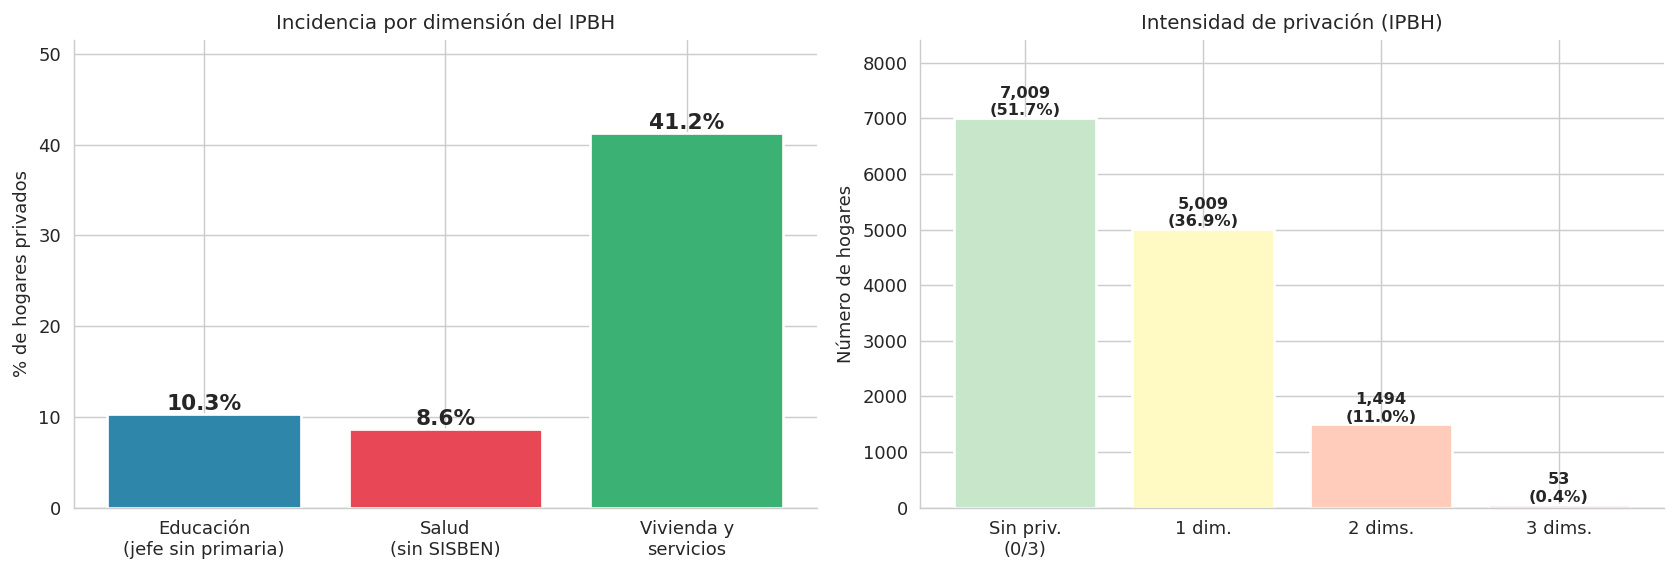

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

dims_labels = ['Educación\n(jefe sin primaria)', 'Salud\n(sin SISBEN)', 'Vivienda y\nservicios']
dims_cols   = ['priv_educacion', 'priv_salud', 'priv_vivienda']
dims_vals   = [df[c].mean()*100 for c in dims_cols if c in df.columns]

axes[0].bar(dims_labels[:len(dims_vals)], dims_vals,
            color=['#2E86AB','#E84855','#3BB273'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(dims_vals):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% de hogares privados')
axes[0].set_title('Incidencia por dimensión del IPBH', fontsize=11)
axes[0].set_ylim(0, max(dims_vals)*1.25 if dims_vals else 10)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

if 'ipbh' in df.columns:
    ipbh_clean = df['ipbh'].dropna().round(3)
    ipbh_counts = ipbh_clean.value_counts().sort_index()
    etiq = {0.0:'Sin priv.\n(0/3)', 0.333:'1 dim.', 0.667:'2 dims.', 1.0:'3 dims.'}
    labels = [etiq.get(round(v,3), f'{v:.2f}') for v in ipbh_counts.index]
    bars2 = axes[1].bar(labels, ipbh_counts.values,
                         color=['#C8E6C9','#FFF9C4','#FFCCBC','#EF9A9A'],
                         edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars2, ipbh_counts.values):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                     f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
    axes[1].set_ylabel('Número de hogares')
    axes[1].set_title('Intensidad de privación (IPBH)', fontsize=11)
    axes[1].set_ylim(0, ipbh_counts.max()*1.2)
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/outputs/eda_ipbh.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Activos y riqueza — el predictor más importante

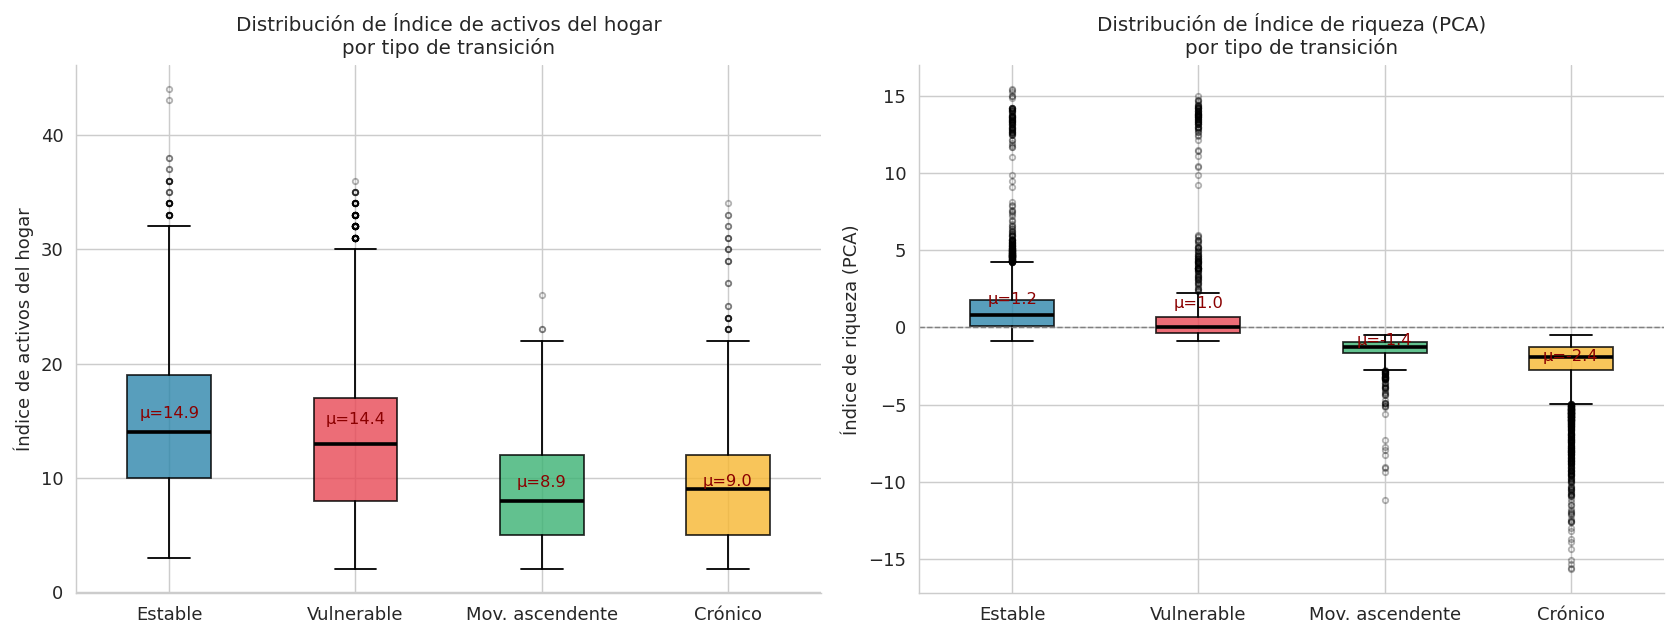

Correlación riqueza–transición: -0.633


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for col, ax, titulo in [('indice_activos', axes[0], 'Índice de activos del hogar'),
                         ('riqueza_pca',   axes[1], 'Índice de riqueza (PCA)')]:
    if col not in df.columns:
        ax.text(0.5, 0.5, f'{col}\nno disponible', ha='center', va='center', transform=ax.transAxes)
        continue

    data_plot = [df[df['transicion']==k][col].dropna().values for k in range(4)]
    bp = ax.boxplot(data_plot, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', alpha=0.3, markersize=3))
    for patch, k in zip(bp['boxes'], range(4)):
        patch.set_facecolor(COLORES[k]); patch.set_alpha(0.8)
    ax.set_xticks(range(1,5))
    ax.set_xticklabels([TRANS[i] for i in range(4)], fontsize=10)
    ax.set_ylabel(titulo)
    ax.set_title(f'Distribución de {titulo}\npor tipo de transición', fontsize=11)
    medias = [df[df['transicion']==k][col].mean() for k in range(4)]
    for i,m in enumerate(medias):
        ax.text(i+1, m+0.3, f'μ={m:.1f}', ha='center', fontsize=9, color='darkred')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if col == 'riqueza_pca':
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('/content/outputs/eda_activos_riqueza.png', dpi=150, bbox_inches='tight')
plt.show()
if 'riqueza_pca' in df.columns and 'transicion' in df.columns:
    corr = df['riqueza_pca'].corr(df['transicion'])
    print(f"Correlación riqueza–transición: {corr:.3f}")

---
## 4. Desigualdad por estrato

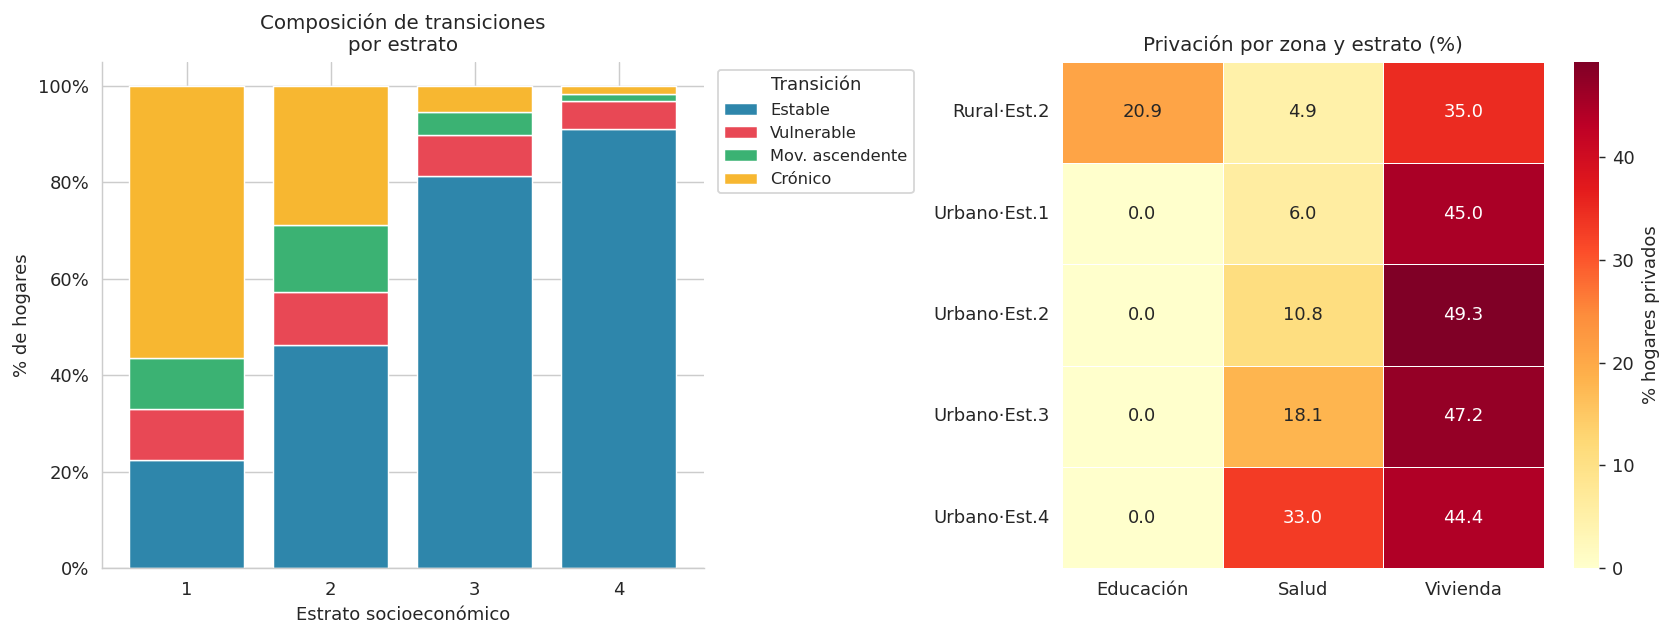

In [6]:
if 'estrato' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Barras apiladas por estrato
    df['estrato_int'] = df['estrato'].dropna().astype(int)
    estratos_validos = sorted(df['estrato_int'].dropna().unique())
    pct_est = pd.crosstab(df['estrato_int'], df['transicion'], normalize='index')*100
    pct_est = pct_est.reindex(columns=range(4), fill_value=0)

    bottom = np.zeros(len(pct_est))
    for i in range(4):
        vals = pct_est[i].values if i in pct_est.columns else np.zeros(len(pct_est))
        axes[0].bar(pct_est.index.astype(str), vals, bottom=bottom,
                    label=TRANS[i], color=COLORES[i], edgecolor='white', linewidth=0.8)
        bottom += vals
    axes[0].set_xlabel('Estrato socioeconómico')
    axes[0].set_ylabel('% de hogares')
    axes[0].set_title('Composición de transiciones\npor estrato', fontsize=11)
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[0].legend(title='Transición', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

    # Heatmap privaciones
    dims_disp = [c for c in ['priv_educacion','priv_salud','priv_vivienda'] if c in df.columns]
    if dims_disp and len(df['zona_label'].unique()) > 1:
        heat = df.groupby(['zona_label','estrato_int'])[dims_disp].mean()*100
        heat.columns = ['Educación','Salud','Vivienda'][:len(dims_disp)]
        heat.index = [f'{z}·Est.{e}' for z,e in heat.index]
        sns.heatmap(heat, ax=axes[1], annot=True, fmt='.1f',
                    cmap='YlOrRd', linewidths=0.5,
                    cbar_kws={'label':'% hogares privados'})
        axes[1].set_title('Privación por zona y estrato (%)', fontsize=11)
        axes[1].set_xlabel(''); axes[1].set_ylabel('')

    plt.tight_layout()
    plt.savefig('/content/outputs/eda_estrato.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Columna estrato no disponible")

---
## 5. Choques climáticos

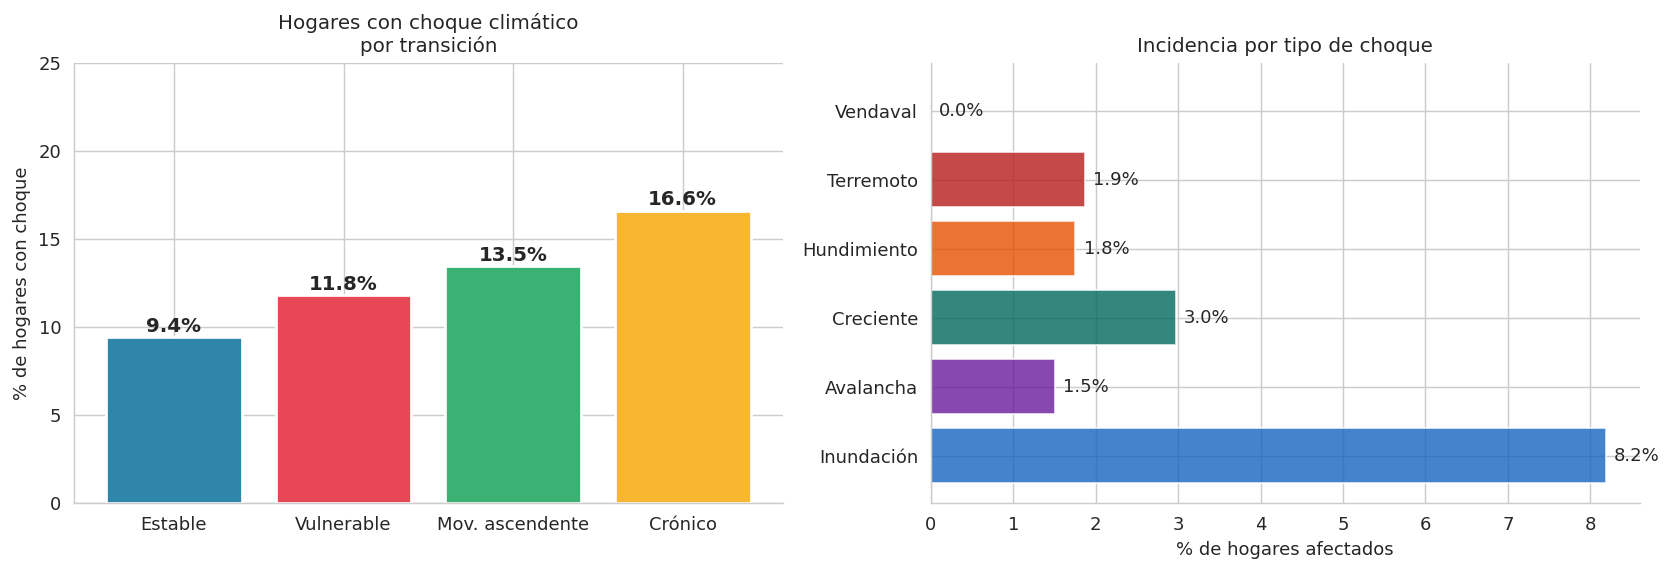

Hogares con choque: 12.3%


In [7]:
if 'tuvo_choque_climatico' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    chq_trans = df.groupby('transicion')['tuvo_choque_climatico'].mean()*100
    bars = axes[0].bar([TRANS[i] for i in chq_trans.index], chq_trans.values,
                        color=[COLORES[i] for i in chq_trans.index], edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, chq_trans.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, val+0.3,
                     f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('% de hogares con choque'); axes[0].set_ylim(0,25)
    axes[0].set_title('Hogares con choque climático\npor transición', fontsize=11)
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

    tipos = ['inundacion','avalancha','creciente','hundimiento','terremoto','vendaval']
    nombres = ['Inundación','Avalancha','Creciente','Hundimiento','Terremoto','Vendaval']
    colores_t = ['#1565C0','#6A1B9A','#00695C','#E65100','#B71C1C','#33691E']
    pcts_t = []
    labels_t = []
    cols_t = []
    for col, nom, color in zip(tipos, nombres, colores_t):
        chk_col = f'choque_{col}'
        if chk_col in df.columns:
            pcts_t.append(df[chk_col].mean()*100)
            labels_t.append(nom)
            cols_t.append(color)

    if pcts_t:
        bars2 = axes[1].barh(labels_t, pcts_t, color=cols_t, alpha=0.8, edgecolor='white')
        for bar, val in zip(bars2, pcts_t):
            axes[1].text(val+0.1, bar.get_y()+bar.get_height()/2,
                         f'{val:.1f}%', va='center', fontsize=10)
        axes[1].set_xlabel('% de hogares afectados')
        axes[1].set_title('Incidencia por tipo de choque', fontsize=11)
        axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('/content/outputs/eda_choques.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Hogares con choque: {df['tuvo_choque_climatico'].mean()*100:.1f}%")

---
## 6. Resiliencia financiera y subsidios

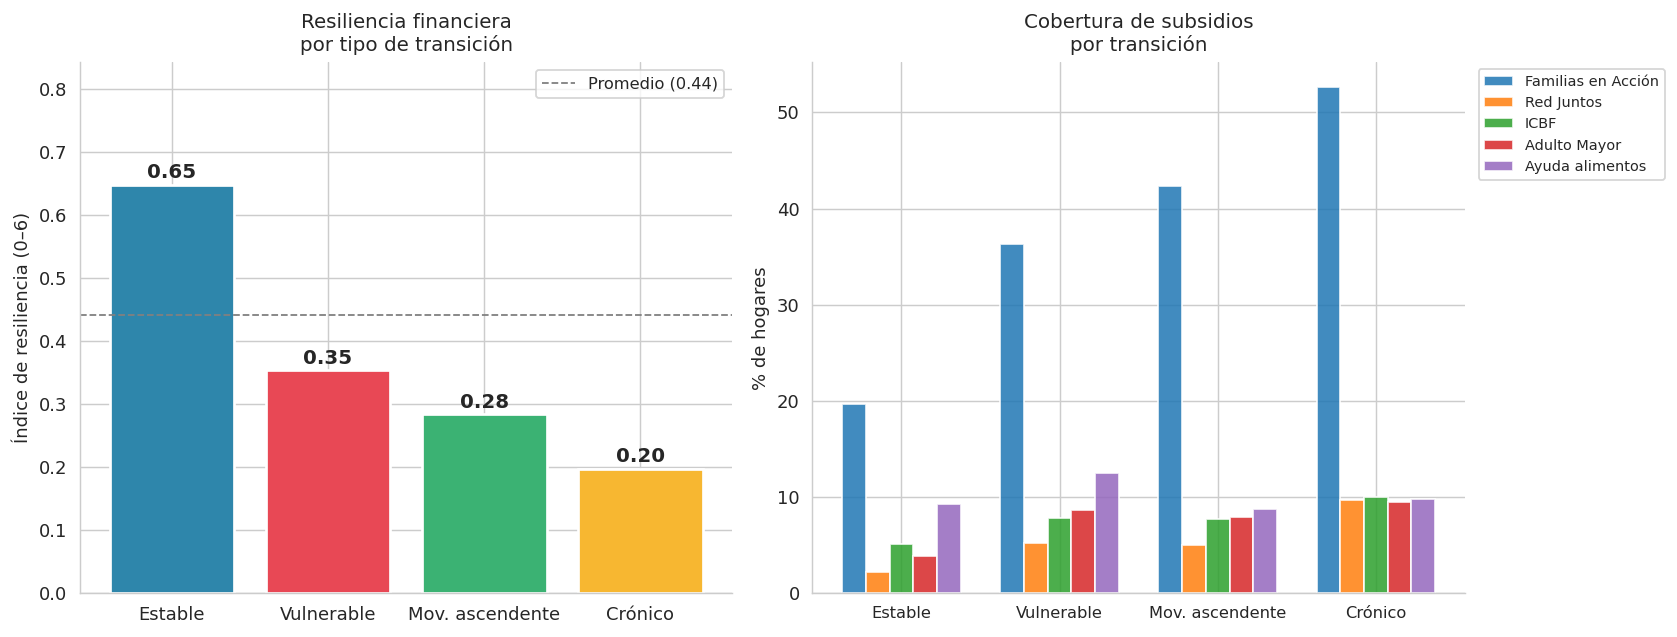

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Resiliencia por transición
if 'indice_resiliencia' in df.columns:
    res_t = df.groupby('transicion')['indice_resiliencia'].mean()
    bars = axes[0].bar([TRANS[i] for i in res_t.index], res_t.values,
                        color=[COLORES[i] for i in res_t.index], edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, res_t.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01,
                     f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Índice de resiliencia (0–6)'); axes[0].set_ylim(0, res_t.max()*1.3)
    axes[0].set_title('Resiliencia financiera\npor tipo de transición', fontsize=11)
    media_g = df['indice_resiliencia'].mean()
    axes[0].axhline(media_g, color='gray', linestyle='--', linewidth=1,
                    label=f'Promedio ({media_g:.2f})')
    axes[0].legend(fontsize=9)
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Subsidios por transición
sub_vars  = [c for c in ['recibe_familias_accion','recibe_red_juntos','recibe_icbf',
                          'recibe_adulto_mayor','recibe_ayuda_alimentos'] if c in df.columns]
sub_names = ['Familias en Acción','Red Juntos','ICBF','Adulto Mayor','Ayuda alimentos'][:len(sub_vars)]

if sub_vars:
    sub_data = df.groupby('transicion')[sub_vars].mean()*100
    w = 0.15
    for i,(col,name) in enumerate(zip(sub_vars, sub_names)):
        axes[1].bar([x+i*w for x in range(4)],
                    [sub_data.loc[k,col] if k in sub_data.index else 0 for k in range(4)],
                    width=w, label=name, alpha=0.85, edgecolor='white')
    axes[1].set_xticks([x+w*2 for x in range(4)])
    axes[1].set_xticklabels([TRANS[i] for i in range(4)], fontsize=9)
    axes[1].set_ylabel('% de hogares'); axes[1].set_title('Cobertura de subsidios\npor transición', fontsize=11)
    axes[1].legend(fontsize=8, bbox_to_anchor=(1.01,1), loc='upper left')
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/outputs/eda_resiliencia_subsidios.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Brecha urbano-rural

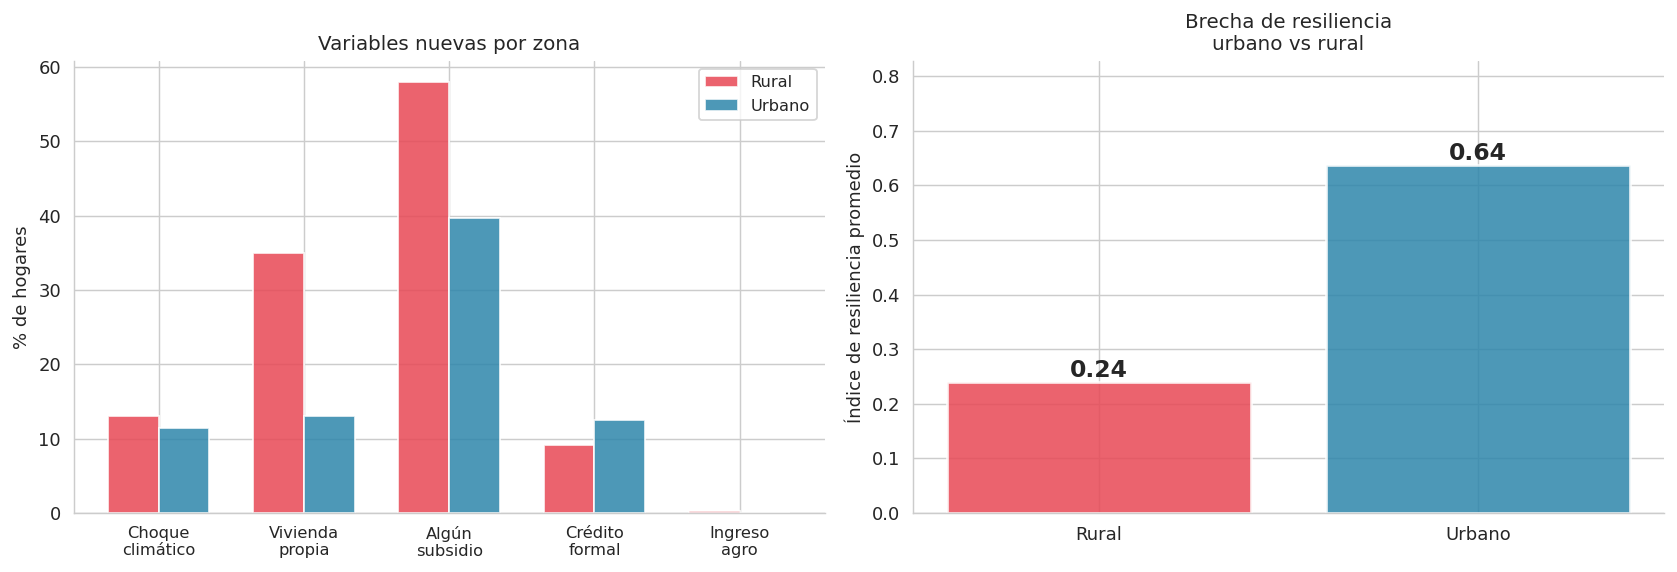

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

vars_comp  = [c for c in ['tuvo_choque_climatico','vivienda_propia','recibe_algun_subsidio',
                            'acceso_credito_formal','tiene_ingresos_agro'] if c in df.columns]
names_comp = ['Choque\nclimático','Vivienda\npropia','Algún\nsubsidio',
              'Crédito\nformal','Ingreso\nagro'][:len(vars_comp)]

if vars_comp and len(df['zona_label'].unique()) > 1:
    rural  = [df[df['zona']==0][v].mean()*100 for v in vars_comp]
    urbano = [df[df['zona']==1][v].mean()*100 for v in vars_comp]
    x = range(len(vars_comp)); w = 0.35
    axes[0].bar([i-w/2 for i in x], rural,  width=w, label='Rural',  color='#E84855', alpha=0.85, edgecolor='white')
    axes[0].bar([i+w/2 for i in x], urbano, width=w, label='Urbano', color='#2E86AB', alpha=0.85, edgecolor='white')
    axes[0].set_xticks(list(x)); axes[0].set_xticklabels(names_comp, fontsize=9)
    axes[0].set_ylabel('% de hogares'); axes[0].set_title('Variables nuevas por zona', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

if 'indice_resiliencia' in df.columns and len(df['zona_label'].unique()) > 1:
    zona_res = df.groupby('zona_label')['indice_resiliencia'].mean()
    axes[1].bar(zona_res.index, zona_res.values,
                color=['#E84855','#2E86AB'], edgecolor='white', linewidth=1.5, alpha=0.85)
    for i,val in enumerate(zona_res.values):
        axes[1].text(i, val+0.01, f'{val:.2f}', ha='center', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Índice de resiliencia promedio'); axes[1].set_ylim(0, zona_res.max()*1.3)
    axes[1].set_title('Brecha de resiliencia\nurbano vs rural', fontsize=11)
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/outputs/eda_brecha_rural.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Matriz de correlaciones

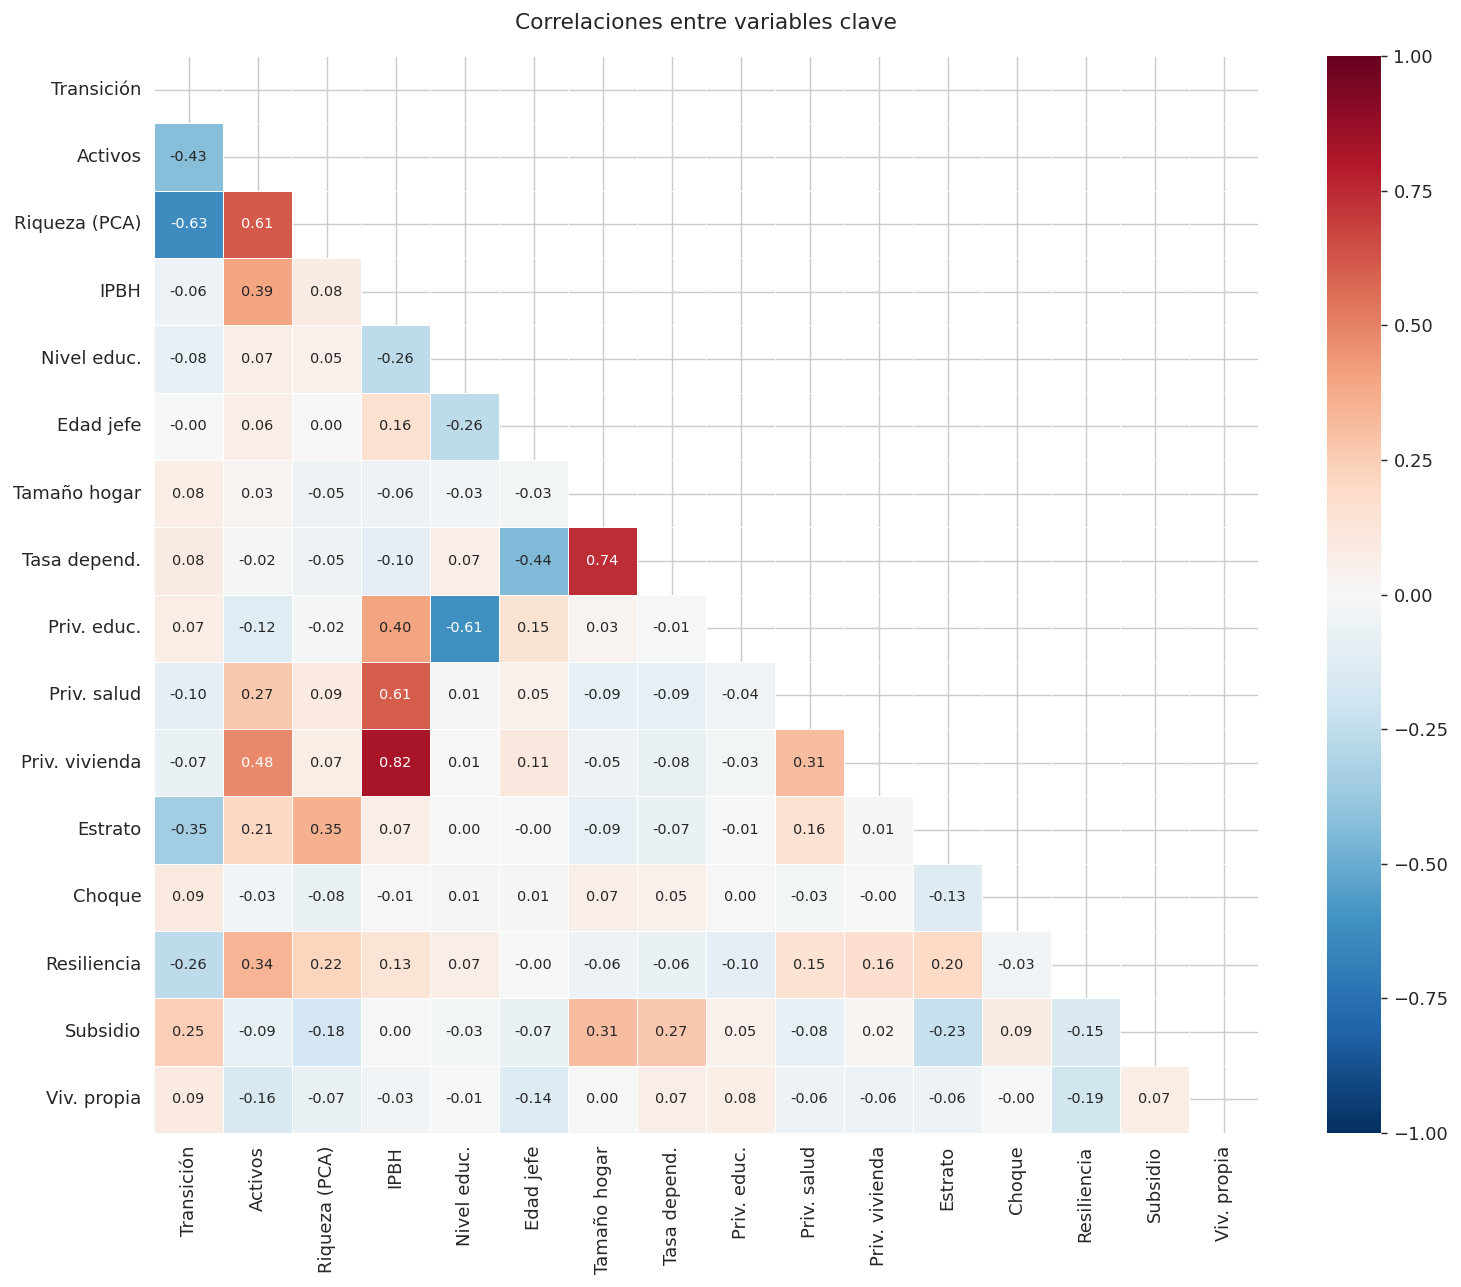

Correlación riqueza–transición: -0.633


In [10]:
cols_corr_base = ['transicion','indice_activos','riqueza_pca','ipbh','grado_educ',
                   'edad','t_personas','tasa_dependencia_proxy','priv_educacion',
                   'priv_salud','priv_vivienda','estrato','tuvo_choque_climatico',
                   'indice_resiliencia','recibe_algun_subsidio','vivienda_propia']
cols_corr = [c for c in cols_corr_base if c in df.columns]

nombres_leg = {
    'transicion':'Transición','indice_activos':'Activos','riqueza_pca':'Riqueza (PCA)',
    'ipbh':'IPBH','grado_educ':'Nivel educ.','edad':'Edad jefe',
    't_personas':'Tamaño hogar','tasa_dependencia_proxy':'Tasa depend.',
    'priv_educacion':'Priv. educ.','priv_salud':'Priv. salud',
    'priv_vivienda':'Priv. vivienda','estrato':'Estrato',
    'tuvo_choque_climatico':'Choque','indice_resiliencia':'Resiliencia',
    'recibe_algun_subsidio':'Subsidio','vivienda_propia':'Viv. propia'
}

df_corr = df[cols_corr].apply(pd.to_numeric, errors='coerce')
corr = df_corr.corr()
corr.index   = [nombres_leg.get(c,c) for c in corr.index]
corr.columns = [nombres_leg.get(c,c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size':8})
ax.set_title('Correlaciones entre variables clave', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('/content/outputs/eda_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

if 'riqueza_pca' in df.columns:
    print(f"Correlación riqueza–transición: {df['riqueza_pca'].corr(df['transicion']):.3f}")

---
## 9. Descargar gráficas

In [ ]:
from google.colab import files

graficas = [
    '/content/outputs/eda_transiciones.png',
    '/content/outputs/eda_ipbh.png',
    '/content/outputs/eda_activos_riqueza.png',
    '/content/outputs/eda_estrato.png',
    '/content/outputs/eda_choques.png',
    '/content/outputs/eda_resiliencia_subsidios.png',
    '/content/outputs/eda_brecha_rural.png',
    '/content/outputs/eda_correlaciones.png',
]

for g in graficas:
    if os.path.exists(g):
        files.download(g)
        print(f"Descargada: {g.split('/')[-1]}")
    else:
        print(f"No generada: {g.split('/')[-1]}")

print("\nListas para insertar en la sección 4 del documento Word.")